## CND LAB #4, 15/11/2024

# Introduction to NetworkX
This notebook provides an introduction to some of the main NetworkX functionalities. <br>
Outline:
1. Creating and visualizing graphs
2. Extracting and analyzing graph properties
3. Generating random graphs
4. Saving and loading graphs
5. Graph algorithms (Dijkstra's shortest path)
6. Max-Multicommodity Flow Problem **(first hands-on assignment)**
7. (if time allows) Routing and Wavelength Assignment Problem **(second hands-on assignment)**
8. Task #3 (deadline 19/11/2024 @15.30)

Additional NetworkX documentation: https://networkx.org/documentation/stable/reference/introduction.html

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import json
import math
from itertools import islice

seed = 0

## 1. Creating and Visualizing Graphs
### 1.1. My first graph
Below, we see how to build a NetworkX graph object and how to populate it with nodes and edges. <br>
We can add nodes and edges one by one using `add_node` and `add_edge`, respecively. <br>
Equivalently, we can add nodes and edges or from lists of nodes and edges using `add_nodes_from` and `add_edges_from`, respectively. <br>
The function `nx.draw` allows us to quickly display our graph along with its node labels.

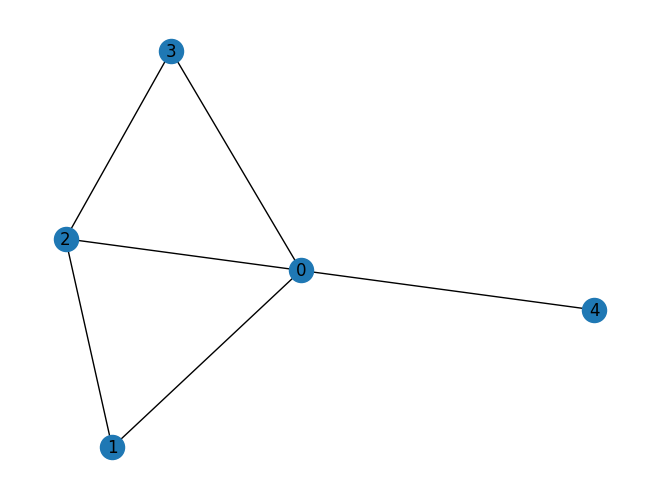

In [3]:
#initialize graph
G = nx.Graph()
#create node
G.add_node(0)
#add nodes
nodes = [i for i in range(1, 4)]
G.add_nodes_from(nodes)
#create edge
G.add_edge(0, 1)
#add edges
edges = [
    (0, 2),
    (0, 3),
    (1, 2),
    (2, 3)
]
#add an edge between 0 and 4
G.add_edge(0, 4)
G.add_edges_from(edges)
#draw graph
nx.draw(G, pos=nx.spring_layout(G, seed=seed), with_labels=True)

### 1.2. Converting node labels to integers
Nodes can have arbitrary labels, which need not to be integer numbers. <br>
It might be however convenient to have node labels corresponding to integer numbers. <br>
Below, we create a 5-node graph with nodes `'a'`, `'b'`, `'c'`, `'d'`, `'e'`. <br>
Using the function `nx.convert_node_labels_to_integers` we can quickly obtain integer labels from arbitrary graphs.

Nodes of G: ['a', 'b', 'c', 'd', 'e']
Edges of G: [('a', 'b'), ('a', 'e'), ('b', 'c'), ('c', 'd'), ('d', 'e')]
Nodes of Q: [0, 1, 2, 3, 4]
Edges of Q: [(0, 1), (0, 4), (1, 2), (2, 3), (3, 4)]


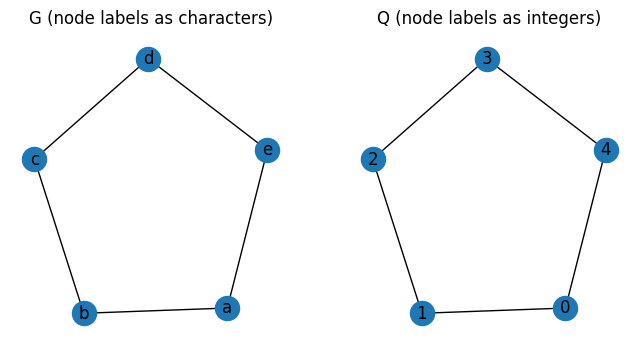

In [5]:
#initialize graph, add graph nodes and edges
G = nx.Graph()
G.add_nodes_from('abcde')
edges = [
    ('a', 'b'),
    ('b', 'c'),
    ('c', 'd'),
    ('d', 'e'),
    ('e', 'a')
]
G.add_edges_from(edges)
#convert node labels to integers
Q = nx.convert_node_labels_to_integers(G)
print(f'Nodes of G: {G.nodes()}')
print(f'Edges of G: {G.edges()}')
print(f'Nodes of Q: {Q.nodes()}')
print(f'Edges of Q: {Q.edges()}')
#plot the graphs
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
ax1.set_title('G (node labels as characters)')
ax2.set_title('Q (node labels as integers)')
nx.draw(G, ax=ax1, pos=nx.spring_layout(G, seed=0), with_labels=True)
nx.draw(Q, ax=ax2, pos=nx.spring_layout(Q, seed=0), with_labels=True)

### 1.3. Directed graphs
Until now we have created and visualized undirected graphs. <br>
We can also create directed graphs using `nx.DiGraph`. <br>
In directed graphs edges have a direction, i.e., edges have a source and a sink node. <br>
The source and sink are specified as first and second argument of `add_edge`.

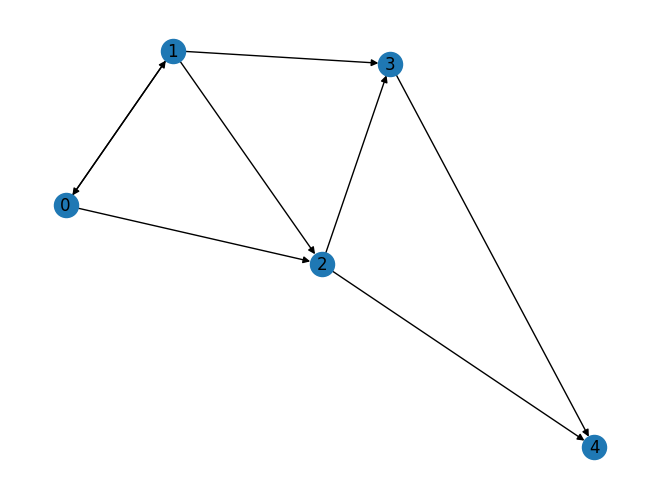

In [6]:
#initialize a directed graph
G = nx.DiGraph()

#add nodes and edges
G.add_node(0)
G.add_node(1)
G.add_node(2)
G.add_node(3)
G.add_node(4)
G.add_edge(0, 1)
G.add_edge(1, 0)
G.add_edge(0, 2)
G.add_edge(1, 2)
G.add_edge(1, 3)
G.add_edge(2, 3)
G.add_edge(3, 4)
G.add_edge(2, 4)

#draw the graph
plt.figure()
nx.draw(G, pos=nx.spring_layout(G, seed=seed), with_labels=True)

## 2. Extracting and Analyzing Graph Properties
### 2.1 Node and Edge Attributes
We can associate attributes to nodes and edges. <br> 
Attributes have a name and can be any data structure. <br>
Below, we associate the attribute `'pos'` to each node, which is a tuple representing the x and y coordinates of the node in a cartesian plane. <br>
Given `'pos'`, for each edge we compute the Euclidean distance between the two endpoints, and associate it to the `'weight'` edge attribute. <br>
We can visualize edge labels with `draw_networkx_edge_labels`.

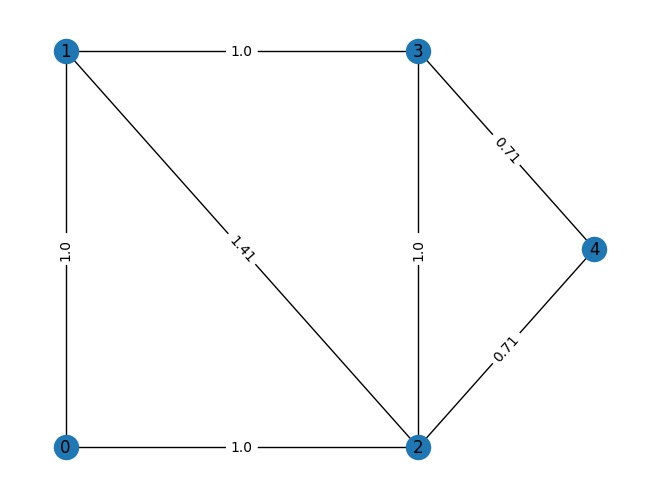

In [ ]:
#initialize graph, add nodes (and their position in 2D) and add edges
G = nx.Graph()
G.add_node(0, pos=(0, 0))
G.add_node(1, pos=(0, 1))
G.add_node(2, pos=(1, 0))
G.add_node(3, pos=(1, 1))
G.add_node(4, pos=(1.5, 0.5))
G.add_edge(0, 1)
G.add_edge(0, 2)
G.add_edge(1, 2)
G.add_edge(1, 3)
G.add_edge(2, 3)
G.add_edge(3, 4)
G.add_edge(2, 4)

#calculate the distance between nodes and set the weight of the edges
for edge in G.edges():
    G.edges[edge]['weight'] = round(math.dist(G.nodes[edge[0]]['pos'], G.nodes[edge[1]]['pos']), 2)
plt.figure()
#draw the graph, including the edge weights
nx.draw(G, pos=nx.get_node_attributes(G, 'pos'), with_labels=True)
nx.draw_networkx_edge_labels(
    G, pos=nx.get_node_attributes(G, 'pos'),
    edge_labels=nx.get_edge_attributes(G, 'weight')
);

### 2.2 Accessing Node and Edge Attributes
We can access the nodes and edges of a graph `G` by calling `G.nodes()` and `G.edges()`, respectively. <br>
The argument `data=True` (e.g., `G.nodes(data=True)` or `G.edges(data=True)`) will also return the dictionary of attributes along with the requested elements.
Indexing a node (e.g., `G[0]`) will return an iterable over the neighbors of that node. We are accessing the entry for that node in the graph adjacency list.

In [9]:
# Access elements of a graph
print("Node information. ", G.nodes(data=True))
print("Link information. ", G.edges(data=False))
print("Info on neighbors of node G[0]. ", G[0])
# Access the position of the neighbor nodes
print("Position of the neighbor nodes of node 0.")
for node in G[0]:
    print(G.nodes[node]['pos'])

Node information.  [(0, {'pos': (0, 0)}), (1, {'pos': (0, 1)}), (2, {'pos': (1, 0)}), (3, {'pos': (1, 1)}), (4, {'pos': (1.5, 0.5)})]
Link information.  [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (2, 4), (3, 4)]
Info on neighbors of node G[0].  {1: {'weight': 1.0}, 2: {'weight': 1.0}}
Position of the neighbor nodes of node 0.
(0, 1)
(1, 0)


### 2.3. More Graph Properties
We can extract several useful properties from a graph. Below is a non-exhaustive example of several important metrics:
* Degree (i.e., #neighbors) for each node. `G.degree`
* Average neighbor degree: average degree of each node's neighbors. `nx.average_neighbor_degree`
* Average degree connectivity: average neighbor degree of nodes that have a given degree. `nx.average_degree_connectivity`
* Diameter: longest shortest path among all node pairs. `nx.diameter`
* Average shortest path length: `nx.average_shortest_path_length`
* Betweenness centrality: measure of how many times each node is traversed by a shortest path. `nx.betweenness_centrality`
* Betweenness edge centrality: measure of how many times each node is traversed by a shortest path. `nx.edge_betweenness_centrality`

In [10]:
# Analyze the graph
print("what is the degree of the node? ", G.degree)
print("what is the average degree of the neighbors? ", nx.average_neighbor_degree(G))
print("what is the average degree connectivity? ", nx.average_degree_connectivity(G))
print("what is the diameter of the network? ", nx.diameter(G))
print("what is the average shortest path? ", nx.average_shortest_path_length(G))
print("Node betweneennes centrality: ", nx.betweenness_centrality(G, normalized=False))
print("Edge betwennes centrality: ", nx.edge_betweenness_centrality(G, normalized=False))

what is the degree of the node?  [(0, 2), (1, 3), (2, 4), (3, 3), (4, 2)]
what is the average degree of the neighbors?  {0: 3.5, 1: 3.0, 2: 2.5, 3: 3.0, 4: 3.5}
what is the average degree connectivity?  {2: 3.5, 3: 3.0, 4: 2.5}
what is the diameter of the network?  2
what is the average shortest path?  1.3
Node betweneennes centrality:  {0: 0.0, 1: 0.5, 2: 2.0, 3: 0.5, 4: 0.0}
Edge betwennes centrality:  {(0, 1): 1.5, (0, 2): 2.5, (1, 2): 1.5, (1, 3): 2.0, (2, 3): 1.5, (2, 4): 2.5, (3, 4): 1.5}


## 3. Generating Random Graphs
NetworkX provides an easy-to-use interface for random graph generators. <br>
Below are a few examples of graphs that might be useful to represent network topologies. <br>
Some functions are not seeded, therefore each execution will yield a different graph. <br>
Feel free to experiment with the parameters and visualize what happens.

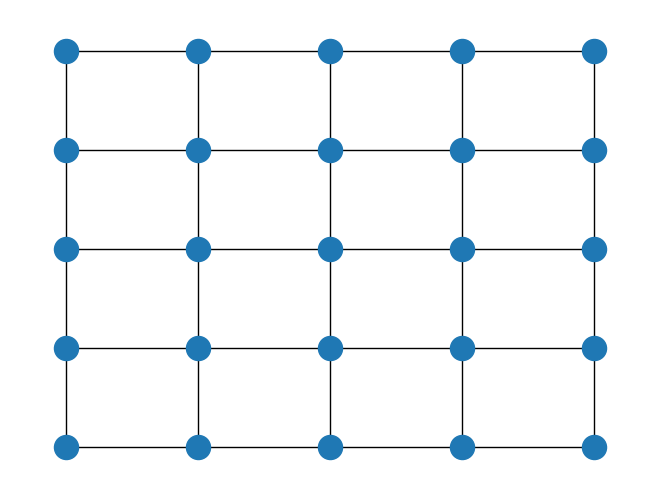

In [11]:
G = nx.grid_2d_graph(5, 5)
pos = {node: position for (node, position) in zip(G.nodes(), G.nodes())}
plt.figure()
nx.draw(G, pos=pos)

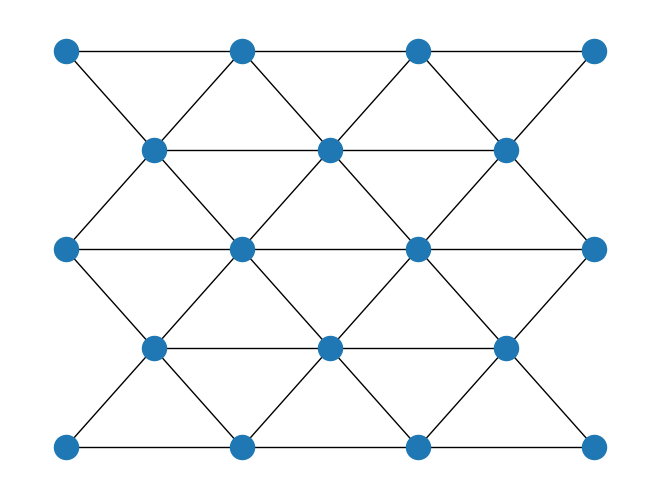

In [12]:
G = nx.triangular_lattice_graph(4, 5, with_positions=True)
plt.figure()
nx.draw(G, nx.get_node_attributes(G, 'pos'))

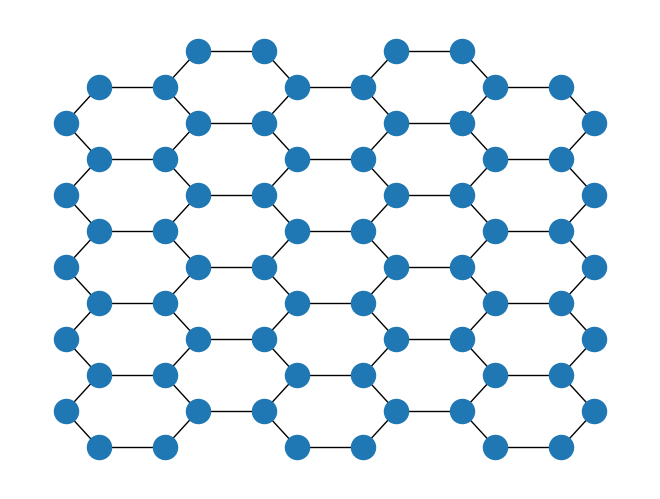

In [13]:
G = nx.hexagonal_lattice_graph(5, 5, with_positions=True)
plt.figure()
nx.draw(G, nx.get_node_attributes(G, 'pos'))

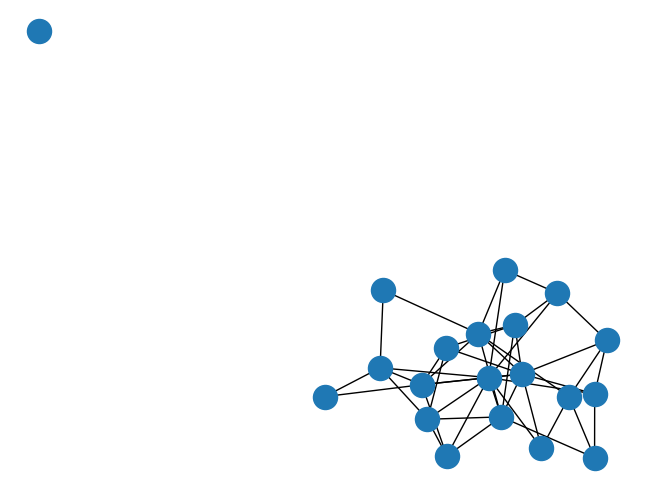

In [14]:
G = nx.fast_gnp_random_graph(20, 0.3)
plt.figure()
nx.draw(G)

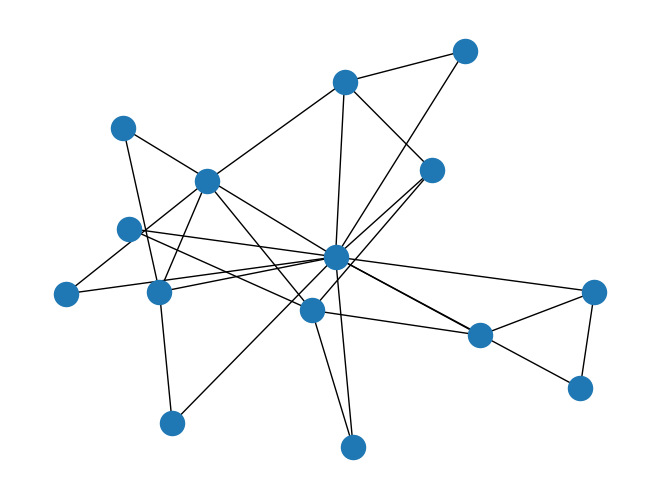

In [15]:
G = nx.barabasi_albert_graph(15, 2)
plt.figure()
nx.draw(G)

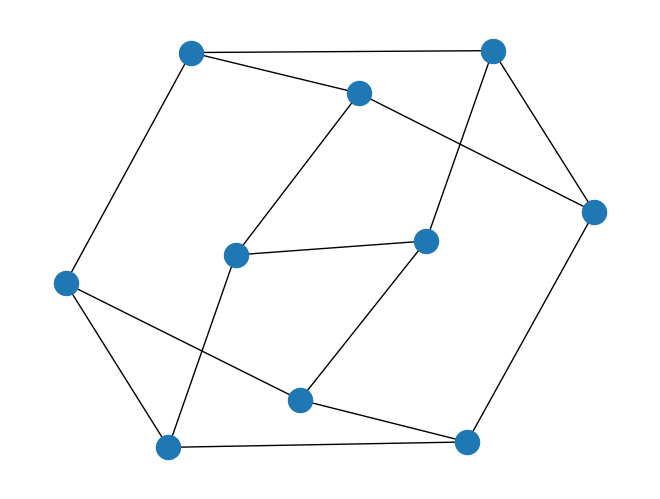

In [16]:
G = nx.random_regular_graph(3, 10)
plt.figure()
nx.draw(G)

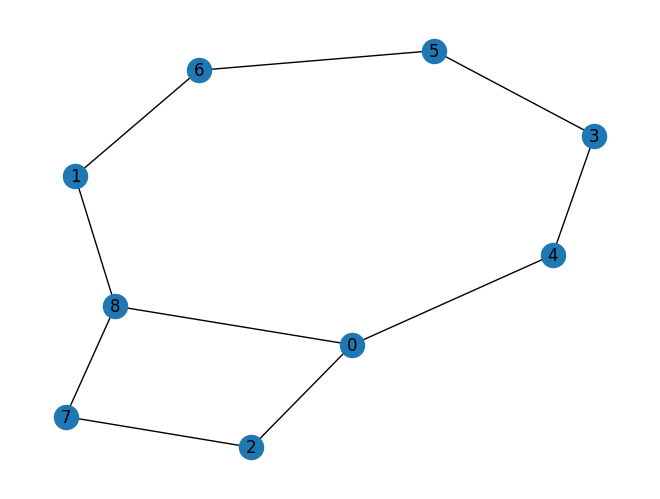

In [17]:
deg_seq = [3, 2, 2, 2, 2, 2, 2, 2, 3]
G = nx.random_degree_sequence_graph(deg_seq)
plt.figure()
nx.draw(G, with_labels=True)

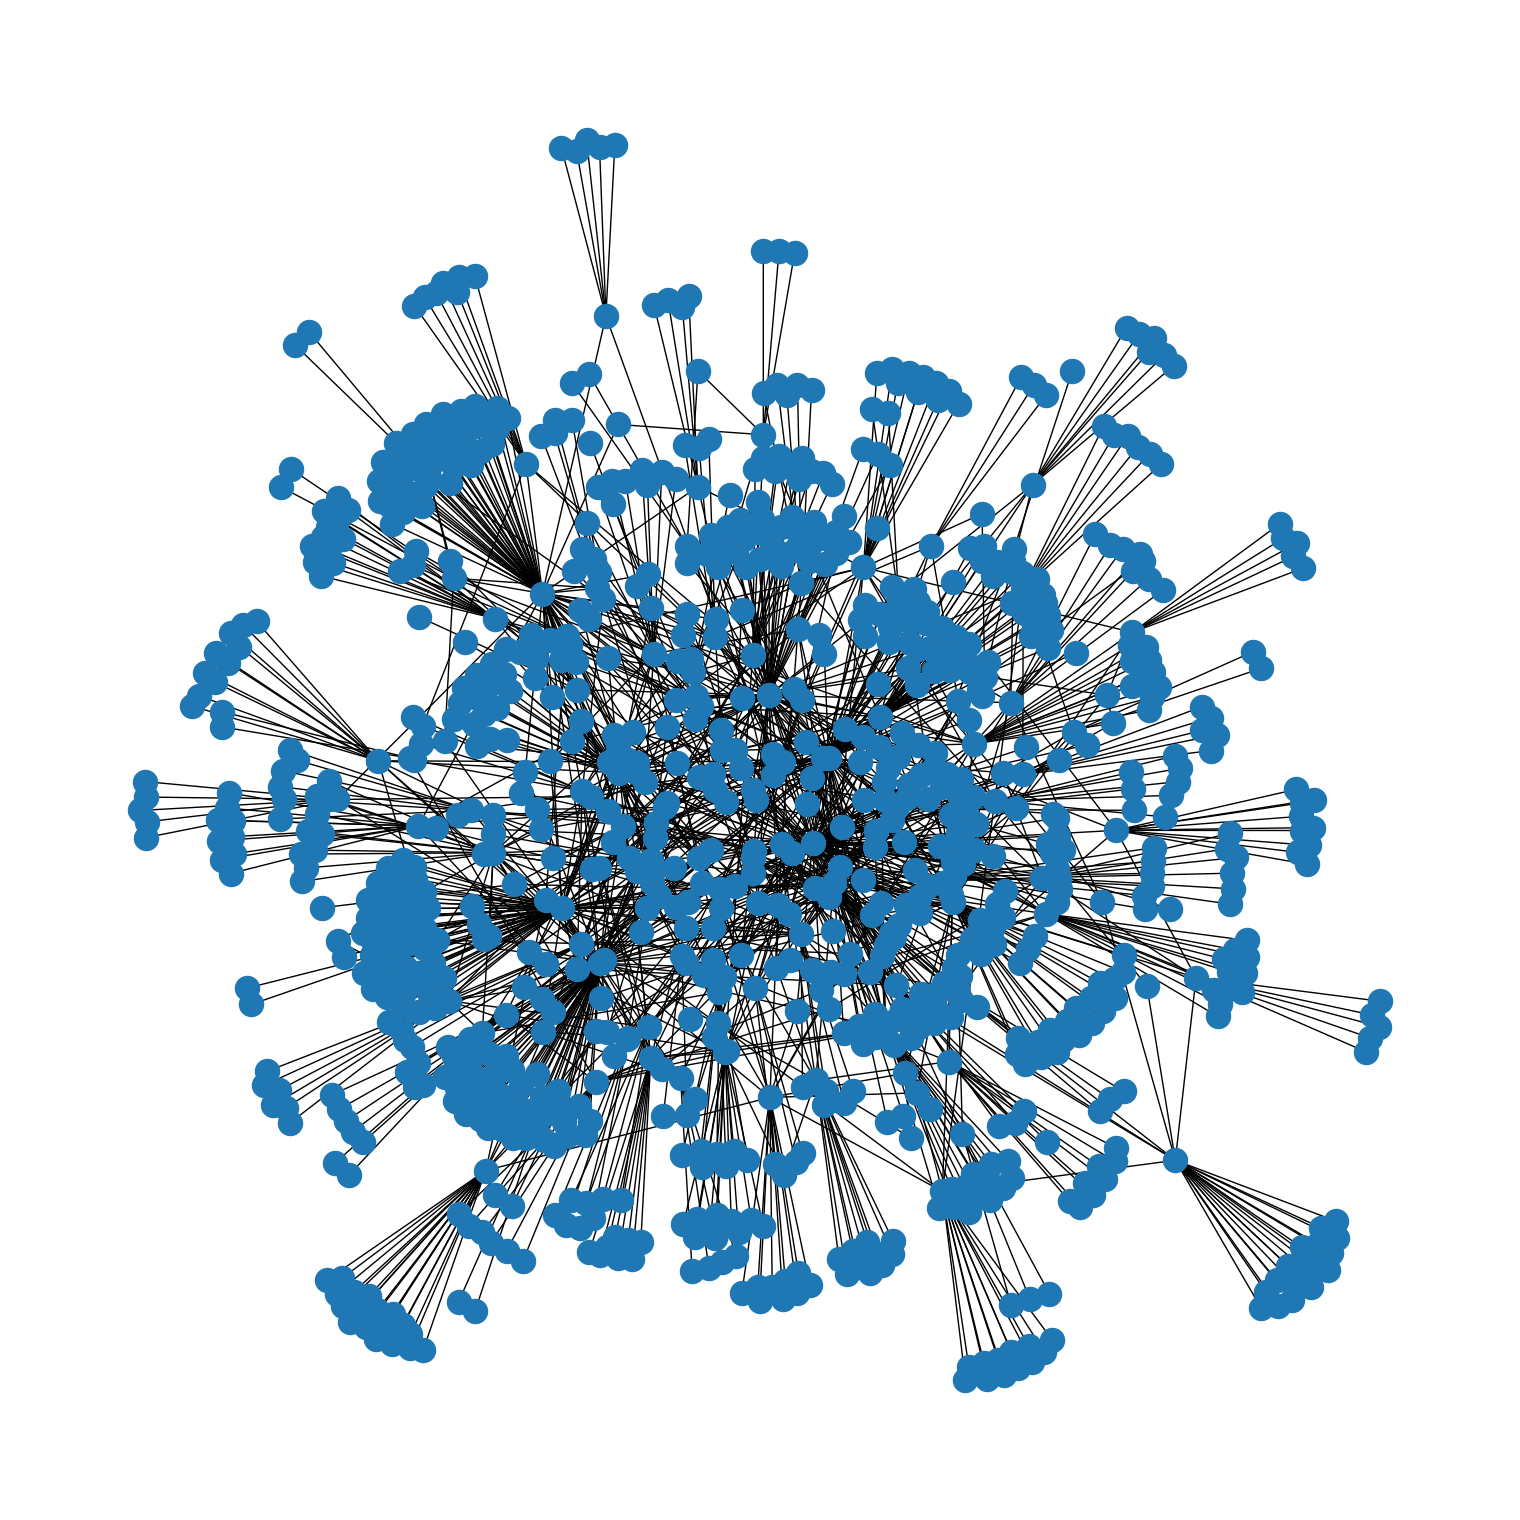

In [18]:
G = nx.random_internet_as_graph(1000)
plt.figure(figsize=(15,15))
nx.draw(G)

## 4. Saving and loading graphs
NetworkX provides several utility functions for saving and loading graphs. <br>
Below, a non-exhaustive list:
* Adjacency list: https://networkx.org/documentation/networkx-1.10/reference/readwrite.adjlist.html
* Edge list: https://networkx.org/documentation/networkx-1.10/reference/readwrite.edgelist.html
* Pickle: https://networkx.org/documentation/networkx-1.10/reference/readwrite.gpickle.html
* JSON: https://networkx.org/documentation/networkx-1.10/reference/readwrite.json_graph.html

In the following, we will see a small example of writing and reading a graph in a JSON file. <br>
JSON is a very flexible file format for representing data. The structure of a JSON file is very similar to a Python dictionary. <br>
It is very useful because it can also encode node and edge attributes. <br>
We will use `nx.node_link_data` followed by `json.dump` to write a graph in JSON file. <br>
Finally, we will use `json.read` followed by `nx.node_link_graph` to read a graph from a JSON file.

C:\Users\IceCould\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\networkx\readwrite\json_graph\node_link.py:142: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(
C:\Users\IceCould\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\networkx\readwrite\json_graph\node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


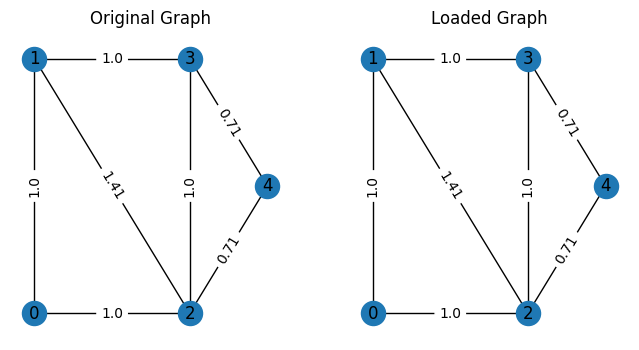

In [19]:
#Create the graph
G = nx.Graph()
G.add_node(0, pos=(0, 0))
G.add_node(1, pos=(0, 1))
G.add_node(2, pos=(1, 0))
G.add_node(3, pos=(1, 1))
G.add_node(4, pos=(1.5, 0.5))
G.add_edge(0, 1)
G.add_edge(0, 2)
G.add_edge(1, 2)
G.add_edge(1, 3)
G.add_edge(2, 3)
G.add_edge(3, 4)
G.add_edge(2, 4)

#Add weights to the edges
for edge in G.edges():
    G.edges[edge]['weight'] = round(math.dist(G.nodes[edge[0]]['pos'], G.nodes[edge[1]]['pos']), 2)
#Plot the graph
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
ax1.set_title('Original Graph')
ax2.set_title('Loaded Graph')
nx.draw(G, ax=ax1, pos=nx.get_node_attributes(G, 'pos'), with_labels=True)
nx.draw_networkx_edge_labels(
    G, ax=ax1, pos=nx.get_node_attributes(G, 'pos'),
    edge_labels=nx.get_edge_attributes(G, 'weight')
);

#specify the path to save the graph data in JSON format
fp = "./graph.json"
#convert the graph G into a dictionary format compatible with JSON
out_data = nx.node_link_data(G)
with open(fp, mode='w') as file:
    json.dump(out_data, file, indent=True)

#load the graph data from the JSON file, and draw the loaded graph
with open(fp, mode='r') as file:
    in_data = json.load(file)
loaded_G = nx.node_link_graph(in_data)
nx.draw(loaded_G, ax=ax2, pos=nx.get_node_attributes(loaded_G, 'pos'), with_labels=True)
nx.draw_networkx_edge_labels(
    loaded_G, ax=ax2, pos=nx.get_node_attributes(loaded_G, 'pos'),
    edge_labels=nx.get_edge_attributes(loaded_G, 'weight')
);

## 5. Graph algorithms
### 5.1. Dijkstra's Shortest Path Algorithm
NetworkX provides an easy-to-use interface for graph algorithms. <br>
In networking, pathfinding algorithms are particularly relevant. Notable examples are Dijkstra's Shortest Path and Yen's K-Shortest Paths. <br>
Below, we generate a random graph and compute the 4 shortest paths between nodes 6 and 8 using `nx.shortest_simple_paths`. <br>
The edges of the shortest paths are plotted so that an edge colour is brighter the more it is traversed by a shortest path.

Path 0: [6, 4, 8]
Path 1: [6, 5, 0, 8]
Path 2: [6, 4, 0, 8]
Path 3: [6, 7, 3, 0, 8]


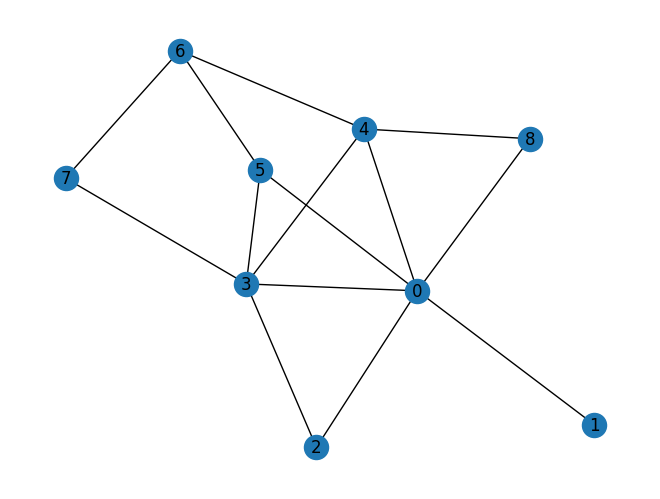

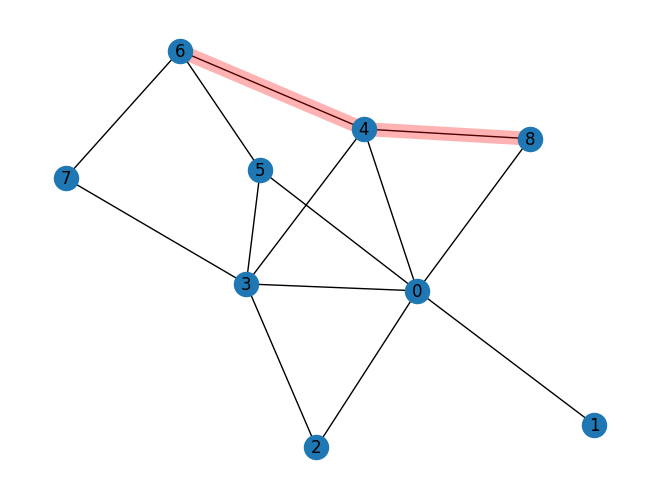

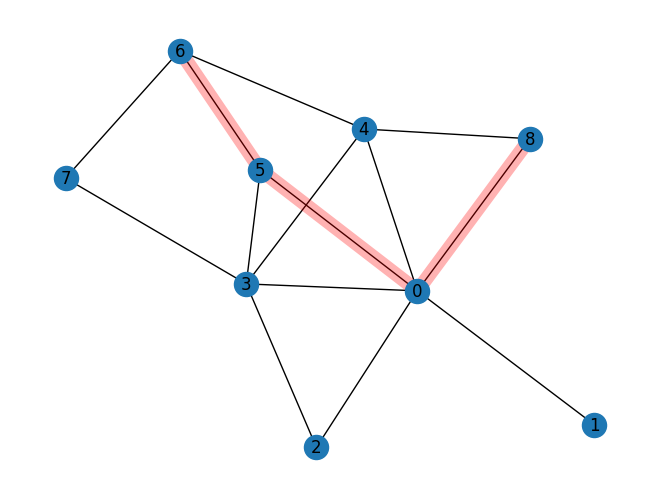

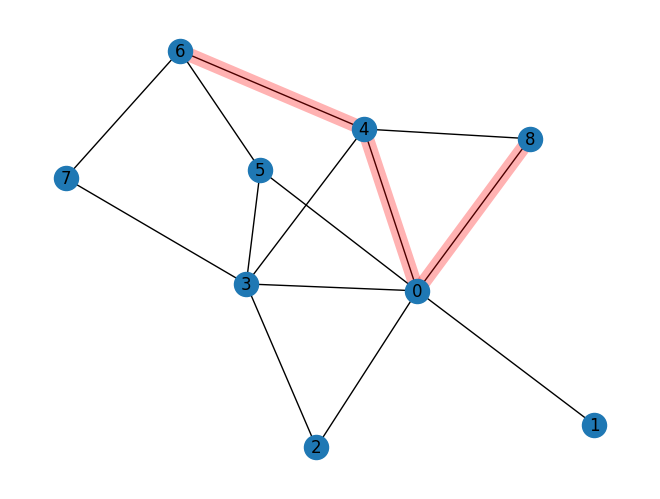

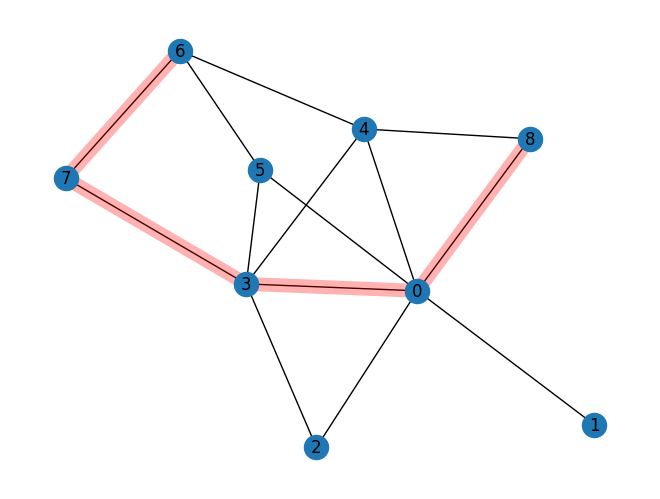

In [21]:
#generate a random graph of 9 nodes using the Barabasi-Albert model and compute a spring layout to visualize the graph
G = nx.barabasi_albert_graph(9, 2, seed=seed)
pos = nx.spring_layout(G, seed=seed)

#compute the k shortest path between nodes 6 and 8, where k = 4
paths = nx.shortest_simple_paths(G, 6, 8)
num_ksp = 4
plt.figure()
nx.draw(G, pos=pos, with_labels=True)
#retrieve and visualize the k shortest paths
for k in range(num_ksp):
    plt.figure()
    nx.draw(G, pos=pos, with_labels=True)
    path0 = next(paths)
    print(f'Path {k}: {path0}')
    edge_list = list(zip(path0, path0[1:]))
    #highlight the edges of the path in red
    nx.draw_networkx_edges(G, pos=pos, edgelist=edge_list, width=10, alpha=0.3, edge_color='red')

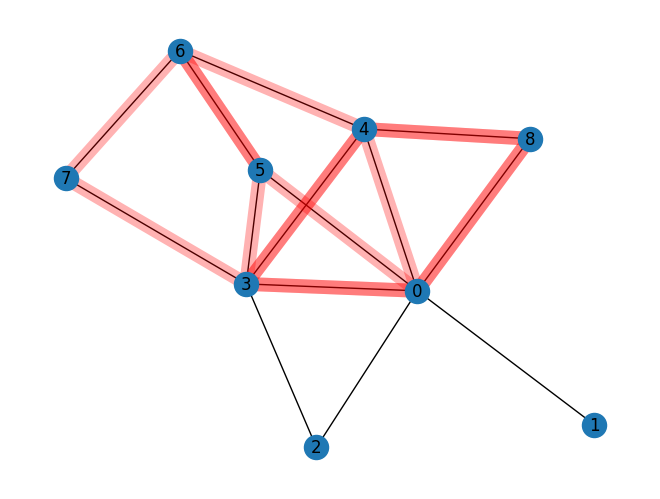

In [22]:
#display all paths together
plt.figure()
nx.draw(G, pos=pos, with_labels=True)
for k in range(num_ksp):
    path0 = next(paths)
    edge_list = list(zip(path0, path0[1:]))
    nx.draw_networkx_edges(G, pos=pos, edgelist=edge_list, width=10, alpha=0.3, edge_color='red')

## 6. Max-Multicommodity Flow Problem
### 6.1. Problem statement
The Multicommodity Flow is a classical optimization problem in networking. <br>
We are given a weighted bidirectional graph $G = (V, E)$ with link capacities $c(u, v), \forall (u, v) \in E$. <br>
We are given demands of $d_i$ units of flow of source nodes $s_i$ and destination nodes $d_i$, $i \in K$. <br>
Demands are routed in flows $f_i(u, v)$, $(u, v) \in E$. <br>
A solution must obey the following constraints:
* Link capacity: the sum of all routed commodities traversing an edge must not exceed link capacity <br>
$\sum_{i=1}^k f_i(u, v) \leq c(u, v) \quad \forall (u, v) \in E$
* Flow conservation on transit nodes: all flows traversing an intermediate node must also exit <br>
$\sum_{w \in V}f_i(u, w) - \sum_{w \in V}f_i(w, u) = 0 \quad \forall i \in K, \; u \neq s_i, \; u \neq t_i$
* Flow conservation between source and destination. <br>
$\sum_{w \in V}f_i(s_i, w) - \sum_{w \in V}f_i(w, s_i) = \sum_{w \in V}f_i(w, t_i) - \sum_{w \in V}f_i(t_i, w) \quad \forall i \in K$
* Maximum demanded flow originated by source nodes. <br>
$\sum_{w \in V}f_i(s_i, w) - \sum_{w \in V}f_i(w, s_i) \leq d_i \quad \forall i \in K$
* Integrality constraint, i.e., flows can only be split in units. <br>
$f_i \in \mathbb{N} \quad \forall i \in K$

We consider the Max-Multicommodity Flow (MMCF) problem. <br>
The objective of the Max-Multicommodity Flow problem is to maximize the number of routed requests (or equivalently, to minimize the number of blocked requests). <br>
The objective function can be therefore formalized as follows: <br>
$\max \sum_{i \in K} f_i$

In the following, we will implement a simple greedy heuristic for the MMCF.

### 6.2e. Setting up the network topology (3-5 min.)
You are provided with a `nsfnet.json` file encodingthe NSFNET backbone network. https://en.wikipedia.org/wiki/National_Science_Foundation_Network <br>
Implement the `get_network_json` function in the block below as follows:
* **Inputs**: file path of the JSON file, link capacity
* **Output**: a NetworkX graph with an additional `"available_capacity"` for each edge properly initialized.

In [10]:
#Please write your code here, based on the pseudocode provided below

#Function get_network_mcf_json(fp: string, link_capacity: integer) -> Graph:
def get_network_mcf_json(fp: str, link_capacity: int) -> nx.Graph:
    #Open the file at path fp in read mode as file
    with open(fp, mode='r') as file:
        #Load JSON data from file into data
        in_data = json.load(file)
    #Convert data into a graph G using node-link format
    G = nx.node_link_graph(in_data)
    #Set the "available_capacity" attribute on all edges of G to link_capacity
    nx.set_edge_attributes(G, link_capacity, "available_capacity")
    #Return the graph G
    return G

<button onclick="this.nextElementSibling.style.display = 
  this.nextElementSibling.style.display === 'none' ? 'block' : 'none'">
  Click here to see the soloution
</button>
<div style="display:none;">
  <!-- This is the solution code -->
  def get_network_mcf_json(fp: str, link_capacity: int) -> nx.Graph:
    with open(fp, "r") as file:
        data = json.load(file)
    G = nx.node_link_graph(data)
    nx.set_edge_attributes(G, link_capacity, "available_capacity")
    return G
</div>

### 6.3e. Generating demands (3-5 min.)
Implement the `generate_demands` function in the block below as follows:
* **Inputs**: a NetworkX graph, the total flow to be routed in the network.
* **Outputs**: a list of source-destination demands.
<br>

**Guidelines**:
* Each demand is represented as a tuple `(src, dst)` containing the source-destination pair.
* Source-destination pairs `(src, dst)` are to be drawn uniformly among all possible node pairs.
* Each demand is for a single flow unit. As such, there may be multiple demands with the same `(src, dst)` pair.

In [4]:
#Please write your code here, based on the pseudocode provided below
from typing import List, Tuple 

#Function generate_demands(G: Graph, total_flow: integer) -> List of Tuples of integers:
def generate_demands(G: nx.Graph, total_flow: int) -> List[Tuple[int, int]]:
    #Initialize an empty list demands
    demands = []
    #For each iteration in the range of total_flow:
    for _ in range(total_flow):
        #Randomly select two distinct nodes, src and dst, from the nodes in graph G
        src, dst = np.random.choice(G.number_of_nodes(), size=(2,), replace=False)
        #Append the tuple (src, dst) to the demands list
        demands.append((src, dst))
    #Return the demands list
    return demands

<button onclick="this.nextElementSibling.style.display = 
  this.nextElementSibling.style.display === 'none' ? 'block' : 'none'">
  Click here to see the soloution
</button>
<div style="display:none;">
  <!-- This is the solution code -->
    from typing import List, Tuple
    def generate_demands(G: nx.Graph, total_flow: int) -> List[Tuple[int, int]]:
        demands = []
        for _ in range(total_flow):
            src, dst = np.random.choice(G.number_of_nodes(), size=(2,), replace=False)
            demands.append((src, dst))
        return demands
</div>

### 6.4e. Generating the K-Shortest Paths (3-5 min.)
Implement the `get_ksp` function in the block below as follows:
* Inputs: a NetworkX graph, the number K of K-shortest paths to compute, a distance metric.
* Outputs: a dictionary `ksp` containing the K-shortest paths for each node pair. <br>
K-shortest paths are to be computed with respect to the provided distance metric, which should match an edge attribute.
<br>

**Guidelines**
* The keys of the dictionary are node pairs. e.g., `ksp[n1, n2]`
* The values of the dictionary are a list of K-shortest paths.
    * K-shortest paths are to be represented as a node list. Values of the dictionary are therefore lists of lists.

**Hint 1**: revise the material at 5.1. <br> 
**Hint 2**: be careful that links are bidirectional, i.e., `ksp[n1, n2]` = `ksp[n2, n1]`

In [5]:
#Please write your code here, based on the pseudocode provided below

#Function get_ksp(G: Graph, n_paths: integer, metric: string) -> Dictionary with tuple keys and list values:
def get_ksp(G: nx.Graph, n_paths: int, metric: str) -> dict[tuple[int, int]: list[int]]:
    #Initialize an empty dictionary ksp
    ksp = {}
    #For each node i in the graph G:
    for i in range(G.number_of_nodes()):
        #For each node j in the graph G:
        for j in range(G.number_of_nodes()):
            #If i is less than j:
            if i < j:
                #Find the first n_paths shortest paths between nodes i and j in G using the specified metric
                #Convert these paths to a list and store in paths
                paths = list(islice(nx.shortest_simple_paths(G, i, j, metric), n_paths))
                #Set ksp[(i, j)] to paths
                ksp[i, j] = paths
                #Set ksp[(j, i)] to paths (to store paths in both directions)
                ksp[j, i] = paths
    #Return the dictionary ksp
    return ksp

<button onclick="this.nextElementSibling.style.display = 
  this.nextElementSibling.style.display === 'none' ? 'block' : 'none'">
  Click here to see the soloution
</button>
<div style="display:none;">
  <!-- This is the solution code -->
    def get_ksp(G: nx.Graph, n_paths: int, metric: str) -> dict[tuple[int, int]: list[int]]:
        ksp = {}
        for i in range(G.number_of_nodes()):
            for j in range(G.number_of_nodes()):
                if i < j:
                    paths = list(islice(nx.shortest_simple_paths(G, i, j, metric), n_paths))
                    ksp[i, j] = paths
                    ksp[j, i] = paths
        return ksp
</div>

### 6.5e. Shortest Available Path for Max-Multicommodity Flow
We implement a simple greedy heuristic, called Shortest Available Path, for the MMCF.
The pseudocode for the algorithm is as follows: <br>
`for each demand:` <br>
&emsp; `for each path between source and destination of the demand:` <br>
&emsp; &emsp; `route on the shortest path that has available capacity` <br>
&emsp; &emsp; `if every path is full, move on to the next demand` <br>
`return the number of routed demands and the routing configuration`
<br>

Implement the `sap_mmcf` function in the block below as follows:
* **Inputs**: a NetworkX graph with `"available_capacity"` edge attributes, a list of demands, a dictionary of paths
* **Outputs**: the number of routed requests, i.e., the value of the objective function. <br>
A list of tuples, with each tuple being `(src, dst, route)` for each routed request, where `route` is the node list of the chosen path.

In [ ]:
#define a function that considers the graph G, demands, and ksp to route the demands
def sap_mmcf(G: nx.Graph, demands: list, ksp: dict) -> tuple[int, list]:
    n_routed_demands = 0
    routed_demands = []
    #For each demand (src, dst) in the demands list:
    for src, dst in demands:
        #For each path in the ksp[(src, dst)] list:
        for path in ksp[src, dst]:
            #Check if the path is free (i.e., all edges have available_capacity > 0)
            is_path_free = True
            #For each edge in the path:
            for i in range(len(path)-1):
                #If the available_capacity of the edge is 0, set is_path_free to False and break
                if G[path[i]][path[i+1]]['available_capacity'] == 0:
                    is_path_free = False
                    continue
            #If the path is free:    
            if is_path_free:
                #Decrement the available_capacity of each edge in the path by 1
                for i in range(len(path)-1):
                    G[path[i]][path[i+1]]['available_capacity'] -= 1
                n_routed_demands += 1
                #Append the demand (src, dst, path) to the routed_demands list
                routed_demands.append((src, dst, path))
                break
    #Return the number of routed demands and the list of routed demands
    return n_routed_demands, routed_demands

C:\Users\IceCould\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\networkx\readwrite\json_graph\node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


Number of routed demands: 75


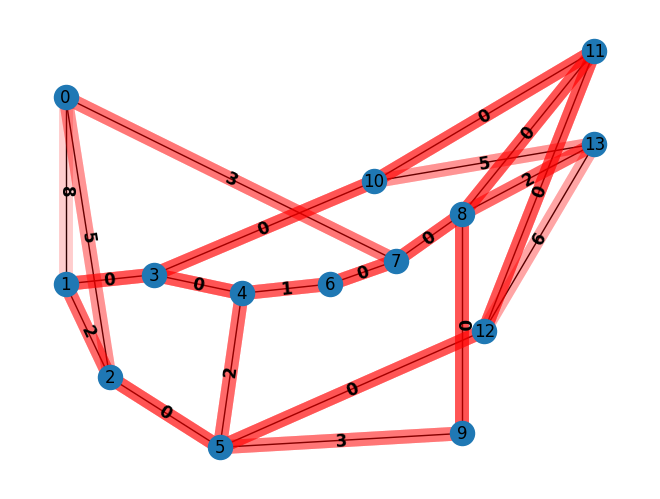

In [11]:
#load the network graph from the JSON file and assign a link capacity of 10 to all edges
G = get_network_mcf_json("C:/Users/IceCould/OneDrive - Politecnico di Milano/Education/Polimi/A研一上/通信网络设计/Lab Material/04 - LAB-CND-4/nsfnet.json", link_capacity=10)
#generate 100 demands in the network
demands = generate_demands(G, 100)
#compute the k shortest paths between nodes in the network
ksp = get_ksp(G, 5, metric='length')

#route the demands using the maximum multi-commodity flow algorithm
n_routed_demands, routed_demands = sap_mmcf(G, demands, ksp)
print(f'Number of routed demands: {n_routed_demands}')
#visualize the network graph with the routed demands
nx.draw(G, pos=nx.get_node_attributes(G, "pos"), with_labels=True)
#highlight the routed demands in red
for demand in routed_demands:
    route = demand[-1]
    route_el = list(zip(route, route[1:]))
    nx.draw_networkx_edges(G, pos=nx.get_node_attributes(G, "pos"), edgelist=route_el, width=10, alpha=0.1, edge_color='red')
#display the avaialble capacity of the edges, showing the remaining capacity after routing the demands
nx.draw_networkx_edge_labels(
    G, pos=nx.get_node_attributes(G, 'pos'),
    edge_labels=nx.get_edge_attributes(G, 'available_capacity'),
    bbox=dict(alpha=0),
    font_size=12,
    font_weight='bold',
    verticalalignment='center');

## 7. Routing and Wavelength Assignment Problem (RWA)
### 7.1. Problem Statement
The Routing and Wavelength Assignment (RWA) is problem in optical networking that extends the Multicommodity flow. <br>
In RWA, given a source-destination demands, we are tasked to provide both a route and a wavelength. <br>
Each optical link in the graph has a number of free wavelengths, similar to the MCF in which each link has available capacity. <br>
Wavelength assigned for a demand must be **continuous** across the whole path. <br>
&emsp; e.g., if we want to assign wavelength 3, we need that wavelength 3 is free **for all edges traversed by the path**.<br>

The mathematical formulation of the problem is as follows: <br>
We are given a weighted bidirectional graph $G = (V, E)$ with $\Lambda(u, v)$ available wavelengths $\forall (u, v) \in E$. <br>
We are given demands source nodes $s_i$ and destination nodes $d_i$, $i \in K$. <br>
Demands are routed in flows $f^{s_i, d}_{i, \lambda}(u, v)$, $\forall (u, v) \in E$, $\lambda = 1, \dots, \Lambda$ <br>

Objective function: 
* Minimze the wavelength consumption. <br>
$\min \sum_{i \in K, \lambda=1, \dots, \Lambda, (u, v) \in E} f_{i, \lambda}(u, v)$


A solution must obey the following constraints:
* Flow conservation on transit nodes: all wavelengths traversing an intermediate node must also exit. <br>
**Note**: we are enforcing wavelength continuity: the wavelengths entering and exiting **must be the same**. <br>
$\sum_{w \in V} f_{i, \lambda}(u, w) - \sum_{w \in V}  f_{i, \lambda}(w, u) = 0 \quad \forall i \in K, \; \lambda=1, \dots, \Lambda, \; u \neq s_i, \; u \neq t_i$
* Flow conservation between source and destination. <br>
**Note**: also here we are enforcing wavelength continuity. <br>
$\sum_{w \in V} f_{i, \lambda}(s_i, w) - \sum_{w \in V} f_{i, \lambda}(w, s_i) = \sum_{w \in V} f_{i, \lambda}(w, t_i) - \sum_{w \in V} f_{i, \lambda}(t_i, w) \quad \forall i \in K, \; \lambda=1, \dots, \Lambda$


* Ensure that each demand is assigned with one path <br>
$\sum_{w \in V, \lambda=1, \dots, \Lambda} f_{i, \lambda}(s_i, w) - \sum_{w \in V, \lambda=1, \dots, \Lambda} f_{i, \lambda}(w, s_i) = 1 \quad \forall i \in K \; $

* Each demand can be assigned to only one wavelength. <br>
$\sum_{\lambda=1}^\Lambda f_{i, \lambda}(u, v) \leq 1 \; \forall i \in K, \; \forall (u, v) \in E$
* Different demands cannot be assigned to the same wavelength in the same link. <br>
$\sum_{i=1}^K f_{i, \lambda}(u, v) \leq 1 \quad \lambda = 1, \dots, \Lambda, \; \forall (u, v) \in E$
* Integrality constraint, i.e., each demand is for one wavelength. <br> 
**Note**: we can have multiple demands with the same source and destination nodes. <br>
$f_{i, \lambda}(u, v) \in \{0, 1\} \quad \forall i \in K, \; \forall \lambda = 1,\dots,\Lambda, \; \forall (u, v) \in E$

### 7.2e. Setting up the network topology (3-5 min.)
You are provided with a `nsfnet.json` file encoding the NSFNET backbone network. https://en.wikipedia.org/wiki/National_Science_Foundation_Network <br>
Implement the `get_network_json` function in the block below as follows:
* **Inputs**: file path of the JSON file, number of wavelengths per link.
* **Output**: a NetworkX graph with an additional `"available_wavelengths"` for each edge properly initialized. <br>
Additionally, add a global graph attribute in the dictionary `G.graph` with the number of wavelengths per link.

**Guidelines**:
* Since we must enforce wavelength continuity, it is better than `"available_wavelengths"` is initialized as an array of ones.
* Be careful that objects in Python are always passed as a reference. <br>
This means that by providing a single array of ones to `nx.set_edge_attributes` will set all edge attributes equal to that single array. <br>
This will cause very undesirable behaviour: modifying the attribute of one edge will result in modifying them all. This will happen silently, without errors or warnings.

In [13]:
#Function get_network_rwa_json(fp: string, n_wavelengths: integer) -> Graph:
def get_network_rwa_json(fp: str, n_wavelengths: int) -> nx.Graph:
    #Open the file at path fp in read mode as file
    with open(fp, "r") as file:
        #Load JSON data from file into data
        data = json.load(file)
    #Convert data into a graph G using node-link format
    G = nx.node_link_graph(data)
    #Initialize an empty dictionary available_wavelengths
    available_wavelengths = {}
    #For each edge in G:
    for edge in G.edges():
        #Set available_wavelengths[edge] to an array of ones with length n_wavelengths and data type uint8
        available_wavelengths[edge] = np.ones((n_wavelengths,), dtype=np.uint8)
    #Set the "available_wavelengths" attribute for all edges in G to the available_wavelengths dictionary
    nx.set_edge_attributes(G, available_wavelengths, "available_wavelengths")
    #Set the graph attribute "n_wavelengths" in G to n_wavelengths
    G.graph["n_wavelengths"] = n_wavelengths
    #Return the graph G
    return G

<button onclick="this.nextElementSibling.style.display = 
  this.nextElementSibling.style.display === 'none' ? 'block' : 'none'">
  Click here to see the soloution
</button>
<div style="display:none;">
  <!-- This is the solution code -->
    def get_network_rwa_json(fp: str, n_wavelengths: int) -> nx.Graph:
        with open(fp, "r") as file:
            data = json.load(file)
        G = nx.node_link_graph(data)
        available_wavelengths = {}
        for edge in G.edges():
            available_wavelengths[edge] = np.ones((n_wavelengths,), dtype=np.uint8)
        nx.set_edge_attributes(G, available_wavelengths, "available_wavelengths")
        G.graph["n_wavelengths"] = n_wavelengths
        return G
</div>

## 7.3e. Shortest Available Path First-Fit for Routing and Wavelength Assignment (8-10 min.)
We implement a simple greedy heuristic, called Shortest Available Path First-Fit, for the RWA. <br>
The pseudocode for the algorithm is as follows: <br>
`for each demand:` <br>
&emsp; `for each path between source and destination of the demand:` <br>
&emsp; &emsp; `route on the shortest path that has at least one continuously available wavelength` <br>
&emsp; &emsp; &emsp; `and assign the first available wavelength on the chosen path` <br>
&emsp; &emsp; `if every path is full, move on to the next demand` <br>
`return the number of routed demands and the routing configuration`
<br>

Implement the `sap_ff_rwa` function in the block below as follows:
* **Inputs**: a NetworkX graph with `"available_wavelengths"` edge attributes, a list of demands, a dictionary of paths
* **Outputs**: the number of routed requests, i.e., the value of the objective function. <br>
A list of tuples `(src, dst, route, wavelength)` for each routed request, where `route` is the node list of the chosen path, `wavelength` is the assigned wavelength.

In [14]:
#Function sap_ff_rwa(G: Graph, demands: List of tuples, ksp: Dictionary) -> Tuple of integer and List:
def sap_ff_rwa(G: nx.Graph, demands: list, ksp: dict) -> tuple[int, list]:
    #Initialize n_routed_demands to 0
    n_routed_demands = 0
    #Initialize an empty list routed_demands
    routed_demands = []
    #For each source-destination pair (src, dst) in demands:
    for src, dst in demands:
        #For each path in ksp[(src, dst)]:
        for path in ksp[src, dst]:
            #For each wavelength wav from 0 to the number of wavelengths in G:
            for wav in range(G.graph["n_wavelengths"]):
                #Set is_wavelength_free to True
                is_wavelength_free = True
                #For each consecutive pair of nodes in the path:
                for i in range(len(path)-1):
                    #If the available wavelength for the edge between these nodes is not free (value is 0):
                    if G[path[i]][path[i+1]]["available_wavelengths"][wav] == 0:
                        #Set is_wavelength_free to False
                        is_wavelength_free = False
                        #Break out of the edge-checking loop
                        break
                #If is_wavelength_free is True:
                if is_wavelength_free:
                    #Break out of the wavelength loop
                    break

            #If is_wavelength_free is True:
            if is_wavelength_free:
                #For each consecutive pair of nodes in the path:
                for i in range(len(path)-1):
                    #Assert that the wavelength wav on the edge between these nodes is free (value is 1)
                    assert(G[path[i]][path[i+1]]["available_wavelengths"][wav] == 1)
                    #Set the wavelength wav on this edge to unavailable (value is 0)
                    G[path[i]][path[i+1]]["available_wavelengths"][wav] = 0
                #Increment n_routed_demands by 1
                n_routed_demands += 1
                #Append the tuple (src, dst, path, wav) to routed_demands
                routed_demands.append((src, dst, path, wav))
                #Break out of the path loop
                break

    #Return the tuple (n_routed_demands, routed_demands)
    return n_routed_demands, routed_demands

<button onclick="this.nextElementSibling.style.display = 
  this.nextElementSibling.style.display === 'none' ? 'block' : 'none'">
  Click here to see the soloution
</button>
<div style="display:none;">
  <!-- This is the solution code -->
    def sap_ff_rwa(G: nx.Graph, demands: list, ksp: dict) -> tuple[int, list]:
      n_routed_demands = 0
      routed_demands = []
      for src, dst in demands:
          for path in ksp[src, dst]:
              for wav in range(G.graph["n_wavelengths"]):
                  for i in range(len(path)-1):
                      is_wavelength_free = True
                      if G[path[i]][path[i+1]]["available_wavelengths"][wav] == 0:
                          is_wavelength_free = False
                          break
                  if is_wavelength_free:
                      break
                  
              if is_wavelength_free:
                  for i in range(len(path)-1):
                      assert(G[path[i]][path[i+1]]["available_wavelengths"][wav] == 1)
                      G[path[i]][path[i+1]]["available_wavelengths"][wav] = 0
                  n_routed_demands += 1
                  routed_demands.append((src, dst, path, wav))
                  break
      return n_routed_demands, routed_demands
</div>

Number of demands: 8
Number of routed demands: 7
Spectrum occupation is: 21


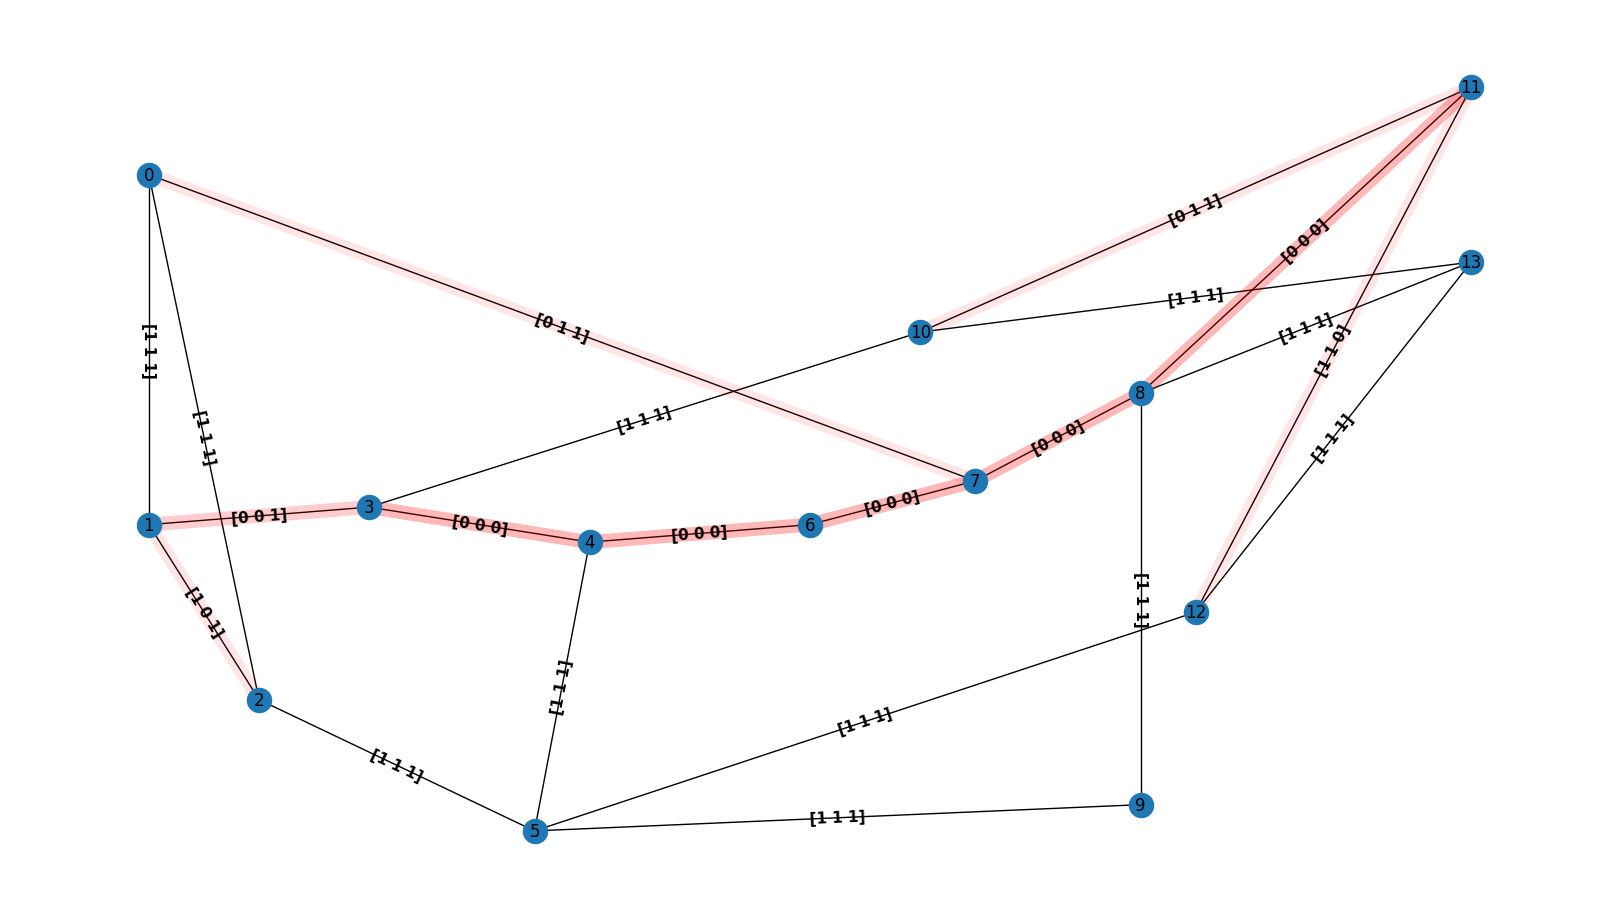

In [24]:
#Initialize num_spectrum to 0
num_spectrum = 0
#Set n_wavelengths to 3
n_wavelengths = 3

#Load the graph G from the JSON file "./nsfnet.json" with n_wavelengths as the number of wavelengths per edge
G = get_network_rwa_json("./nsfnet.json", n_wavelengths=n_wavelengths)
#Generate a list of demands using the function generate_demands with G and a total of 12 demands
#demands = generate_demands(G, 12)
demands = [
    (0, 7), (1, 7), (2, 7), (3, 7),
    (7, 10), (7, 11), (7, 12), (7, 13)
]
#Generate the k-shortest paths (ksp) dictionary for G with up to 5 paths per node pair, using 'length' as the metric
ksp = get_ksp(G, 5, metric='length')

#Print the number of demands in the demands list
print(f'Number of demands: {len(demands)}')
#Call the sap_ff_rwa function with G, demands, and ksp, and store the results in n_routed_demands and routed_demands
n_routed_demands, routed_demands = sap_ff_rwa(G, demands, ksp)
#Print the number of routed demands
print(f'Number of routed demands: {n_routed_demands}')
#Initialize a plot plt_1 with a figure size of 16 by 9
plt_1 = plt.figure(figsize=(16, 9))
#Draw the graph G with node positions and labels
nx.draw(G, pos=nx.get_node_attributes(G, "pos"), with_labels=True)

#For each demand in routed_demands:
for demand in routed_demands:
    #Extract the route path from the demand
    route = demand[-2]
    #Create an edge list route_el from consecutive node pairs in the route path
    route_el = list(zip(route, route[1:]))
    #Add the length of route_el to num_spectrum
    num_spectrum += len(route_el)
    #Draw the edges in route_el on the graph G in red with a width of 10 and transparency (alpha) of 0.1
    nx.draw_networkx_edges(G, pos=nx.get_node_attributes(G, "pos"), edgelist=route_el, width=10, alpha=0.1, edge_color='red')

#Draw the edge labels for each edge in G, using the "available_wavelengths" attribute as the label, with:
nx.draw_networkx_edge_labels(G, pos=nx.get_node_attributes(G, 'pos'), edge_labels=nx.get_edge_attributes(G, 'available_wavelengths'),
    #Transparent background (alpha=0)
    bbox=dict(alpha=0),
    #Font size 11 and bold weight
    font_size=11, font_weight='bold',
    #Centered vertical alignment
    verticalalignment='center');

#Print "Spectrum occupation is: " followed by the value of num_spectrum
print("Spectrum occupation is: " + str(num_spectrum))

<button onclick="this.nextElementSibling.style.display = 
  this.nextElementSibling.style.display === 'none' ? 'block' : 'none'">
  Click here to see the soloution
</button>
<div style="display:none;">
  <!-- This is the solution code -->
    num_spectrum = 0
    n_wavelengths = 3

    G = get_network_rwa_json("./nsfnet.json", n_wavelengths=n_wavelengths)
    demands = generate_demands(G, 12)
    ksp = get_ksp(G, 5, metric='length')

    print(f'Number of demands: {len(demands)}')
    n_routed_demands, routed_demands = sap_ff_rwa(G, demands, ksp)
    print(f'Number of routed demands: {n_routed_demands}')
    plt_1 = plt.figure(figsize=(16, 9))
    nx.draw(G, pos=nx.get_node_attributes(G, "pos"), with_labels=True)
    for demand in routed_demands:
        route = demand[-2]
        route_el = list(zip(route, route[1:]))
        num_spectrum += len(route_el)
        nx.draw_networkx_edges(G, pos=nx.get_node_attributes(G, "pos"), edgelist=route_el, width=10, alpha=0.1, edge_color='red')
    nx.draw_networkx_edge_labels(
        G, pos=nx.get_node_attributes(G, 'pos'),
        edge_labels=nx.get_edge_attributes(G, 'available_wavelengths'),
        bbox=dict(alpha=0),
        font_size=11,
        font_weight='bold',
        verticalalignment='center');
    print("Spectrum occupation is: " + str(num_spectrum))
</div>

## TASK #3: Solve the RWA problem with ILP

## DEADLINE: 19-November-2024, 15.30


## Task 3 description

- Compare the result of ILP with the heuristic, for the NSF-NET network topology
- Consider five traffic matrixes (TM1, TM2, TM3, TM4, TM5). Ensure to explicitly clarify how you have considered the traffic matrixes
- Plot the results in barplots (one bar for ILP, one bar for Heuristic)
- Y-axis is the value of the objetive function
- X-axis is the different traffic matrixes (TM1, TM2, TM3, TM4, TM5)

### You need to submit the following
1. The code, with comments
2. The written report, in which you explain the inputs (description on the traffic matrixes), and comment the results
 

In [ ]:
# Prepare sets of the ILP

# Set of nodes
V = list(G.nodes)
print(V)

# Set of edges
E_u = list(G.edges())
E = []
for e in E_u:
    E.append(e)
    E.append((e[1], e[0]))
print(E)

# E = E_u
print(G[1][2]["available_wavelengths"])
print(G[2][1]["available_wavelengths"])
G[1][2]["available_wavelengths"][0] = 0
print(G[1][2]["available_wavelengths"])
print(G[2][1]["available_wavelengths"])

print(demands)
# set of demands
K = list(range(len(demands)))
print(K)
# source node and destination node of the demands
s = {}
t = {}
for k in K:
    s[k] = demands[k][0]
    t[k] = demands[k][1]
print(s)
print(t)

# set of wavelengths
Lambda = list(range(n_wavelengths))
print(Lambda)

# Prepare parameters of the ILP



[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
[(0, 1), (1, 0), (0, 2), (2, 0), (0, 7), (7, 0), (1, 2), (2, 1), (1, 3), (3, 1), (2, 5), (5, 2), (3, 4), (4, 3), (3, 10), (10, 3), (4, 5), (5, 4), (4, 6), (6, 4), (5, 9), (9, 5), (5, 12), (12, 5), (6, 7), (7, 6), (7, 8), (8, 7), (8, 9), (9, 8), (8, 11), (11, 8), (8, 13), (13, 8), (10, 11), (11, 10), (10, 13), (13, 10), (11, 12), (12, 11), (12, 13), (13, 12)]
[0 0 0]
[0 0 0]
[0 0 0]
[0 0 0]
[(np.int32(6), np.int32(2)), (np.int32(6), np.int32(10)), (np.int32(2), np.int32(7)), (np.int32(7), np.int32(1)), (np.int32(1), np.int32(3)), (np.int32(2), np.int32(3)), (np.int32(13), np.int32(3)), (np.int32(10), np.int32(7)), (np.int32(8), np.int32(12)), (np.int32(9), np.int32(8)), (np.int32(1), np.int32(12)), (np.int32(4), np.int32(2))]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
{0: np.int32(6), 1: np.int32(6), 2: np.int32(2), 3: np.int32(7), 4: np.int32(1), 5: np.int32(2), 6: np.int32(13), 7: np.int32(10), 8: np.int32(8), 9: np.int32(9), 10: np.int32(1),

In [ ]:
from ortools.linear_solver import pywraplp

# Create the SCIP solver.
solver = pywraplp.Solver.CreateSolver('SCIP')
if not solver:
    print("SCIP solver not found.")


### Define variables

In [ ]:
# variable definition


## Add Constraints

In [ ]:
# flow conservation constraints on intermediate ndoes

# flow conservation constraints on source and destination nodes


In [ ]:
# each demand can only be assigned to one wavelength

# different demands cannot use the same wavelength on the same link


## Objective function

In [ ]:
# objective function


In [ ]:
#print the solution status and objective function
